# Reprodução didática de DDPM e DDIM em MNIST

Este notebook reproduz o núcleo algorítmico de **Denoising Diffusion Probabilistic Models** (Ho, Jain e Abbeel, 2020) e **Denoising Diffusion Implicit Models** (Song, Meng e Ermon, 2021). O tutorial e o survey da pasta `articles` são usados como apoio teórico.

O objetivo é verificar o processo direto, treinar o objetivo simplificado $L_{simple}$ e comparar a amostragem DDPM com a DDIM determinística. MNIST e uma rede pequena substituem CIFAR-10/LSUN para que o experimento possa ser executado durante um seminário; portanto, os valores de FID e Inception Score dos artigos **não** são reproduzidos.

## 1. Ambiente e configuração

Execute o notebook pelo ambiente criado com `uv sync`. O modo rápido é o padrão; mude `QUICK_RUN` para `False` para usar todo o MNIST e mais épocas.

In [64]:
import json
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
QUICK_RUN = False
RETRAIN = False
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 1_000
EPOCHS = 20 if QUICK_RUN else 50
TRAIN_SAMPLES = 5_000 if QUICK_RUN else 60_000
VALID_SAMPLES = 2_000 if QUICK_RUN else 10_000
BATCH_SIZE = 128

ROOT = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "seminar_1" / "data" / "mnist" / "source"
CHECKPOINT = ROOT / "seminar_1" / "data" / "mnist" / "models" / "ddpm_mnist_metrics.pt"
METRICS_DIR = ROOT / "seminar_1" / "data" / "mnist" / "metrics"
CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
print(f"device={DEVICE}, T={T}, amostras={TRAIN_SAMPLES}, épocas={EPOCHS}")

device=cpu, T=1000, amostras=60000, épocas=50


## 2. Dados

As imagens são normalizadas para $[-1, 1]$, mesma faixa usada pela saída do processo de geração.

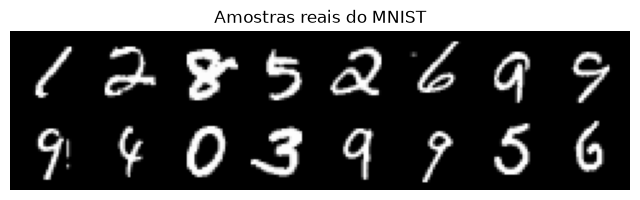

In [65]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
valid_data = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)
if TRAIN_SAMPLES < len(train_data):
    indices = torch.randperm(len(train_data), generator=torch.Generator().manual_seed(SEED))[:TRAIN_SAMPLES]
    train_data = Subset(train_data, indices)
if VALID_SAMPLES < len(valid_data):
    valid_data = Subset(valid_data, range(VALID_SAMPLES))
train_loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=DEVICE.type == "cuda"
)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, _ = next(iter(train_loader))
grid = make_grid((images[:16] + 1) / 2, nrow=8)
plt.figure(figsize=(8, 2.2))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Amostras reais do MNIST")
plt.show()

## 3. Processo direto $q(x_t \mid x_0)$

Com $\alpha_t=1-\beta_t$ e $\bar\alpha_t=\prod_{s=1}^{t}\alpha_s$, qualquer estado ruidoso pode ser obtido diretamente:

$$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon, \qquad \epsilon\sim\mathcal{N}(0,I).$$

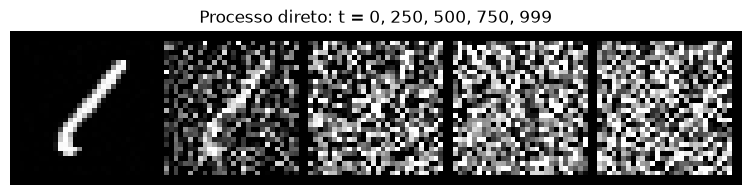

In [66]:
schedule_scale = 1_000 / T
betas = torch.linspace(schedule_scale * 1e-4, schedule_scale * 2e-2, T, device=DEVICE)
alphas = 1 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_previous = F.pad(alpha_bars[:-1], (1, 0), value=1.0)
posterior_variance = betas * (1 - alpha_bars_previous) / (1 - alpha_bars)

def extract(values, timesteps, shape):
    return values[timesteps].view(timesteps.shape[0], *((1,) * (len(shape) - 1)))

def q_sample(x0, timesteps, noise=None):
    noise = torch.randn_like(x0) if noise is None else noise
    mean = extract(alpha_bars.sqrt(), timesteps, x0.shape) * x0
    std = extract((1 - alpha_bars).sqrt(), timesteps, x0.shape)
    return mean + std * noise, noise

# Verificação mínima das invariantes usadas por treino e amostragem.
assert alpha_bars.shape == (T,) and torch.all(alpha_bars[1:] < alpha_bars[:-1])
probe, _ = q_sample(images[:4].to(DEVICE), torch.tensor([0, T // 3, 2 * T // 3, T - 1], device=DEVICE))
assert probe.shape == images[:4].shape

steps = torch.tensor([0, T // 4, T // 2, 3 * T // 4, T - 1], device=DEVICE)
x0 = images[:1].to(DEVICE).repeat(len(steps), 1, 1, 1)
noisy, _ = q_sample(x0, steps)
grid = make_grid((noisy.cpu() + 1) / 2, nrow=len(steps))
plt.figure(figsize=(10, 2))
plt.imshow(grid.permute(1, 2, 0).clip(0, 1))
plt.axis("off")
plt.title("Processo direto: t = " + ", ".join(map(str, steps.tolist())))
plt.show()

## 4. Preditor de ruído

A rede recebe $x_t$ e o passo $t$. Ela é deliberadamente pequena para o seminário, mas mantém condicionamento temporal senoidal e conexões residuais entre resoluções.

In [67]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, size=32):
        super().__init__()
        half = size // 2
        self.register_buffer("frequencies", torch.exp(-math.log(10_000) * torch.arange(half) / (half - 1)))

    def forward(self, timesteps):
        angles = timesteps[:, None].float() * self.frequencies[None]
        return torch.cat((angles.sin(), angles.cos()), dim=1)

class TinyDenoiser(nn.Module):
    def __init__(self):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTimeEmbedding(), nn.Linear(32, 64), nn.SiLU())
        self.time1 = nn.Linear(64, 32)
        self.time2 = nn.Linear(64, 64)
        self.time3 = nn.Linear(64, 64)
        self.down1 = nn.Conv2d(1, 32, 3, padding=1)
        self.down2 = nn.Conv2d(32, 64, 4, stride=2, padding=1)
        self.down3 = nn.Conv2d(64, 64, 4, stride=2, padding=1)
        self.up1 = nn.ConvTranspose2d(64, 64, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.output = nn.Conv2d(32, 1, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, 32)
        self.norm2 = nn.GroupNorm(8, 64)
        self.norm3 = nn.GroupNorm(8, 64)
        self.norm4 = nn.GroupNorm(8, 64)
        self.norm5 = nn.GroupNorm(8, 32)

    def forward(self, x, timesteps):
        time_embedding = self.time(timesteps)
        h1 = F.silu(self.norm1(self.down1(x) + self.time1(time_embedding)[:, :, None, None]))
        h2 = F.silu(self.norm2(self.down2(h1) + self.time2(time_embedding)[:, :, None, None]))
        h3 = F.silu(self.norm3(self.down3(h2) + self.time3(time_embedding)[:, :, None, None]))
        h = F.silu(self.norm4(self.up1(h3) + h2))
        h = F.silu(self.norm5(self.up2(h) + h1))
        return self.output(h)

model = TinyDenoiser().to(DEVICE)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
assert model(torch.zeros(2, 1, 28, 28, device=DEVICE), torch.tensor([0, T - 1], device=DEVICE)).shape == (2, 1, 28, 28)
print(f"{parameter_count:,} parâmetros treináveis")

210,465 parâmetros treináveis


## 5. Treino, validação e evolução temporal

A cada lote sorteamos $t$ e $\epsilon$ e minimizamos $\lVert\epsilon-\epsilon_\theta(x_t,t)\rVert_2^2$, conforme o Algoritmo 1 do DDPM. Registramos MSE de treino/validação, duração e vazão por época. O checkpoint `ddpm_mnist_metrics.pt` preserva pesos e histórico; use `RETRAIN=True` para medi-los novamente.

Checkpoint e histórico carregados de /home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_1/data/mnist/models/ddpm_mnist_metrics.pt


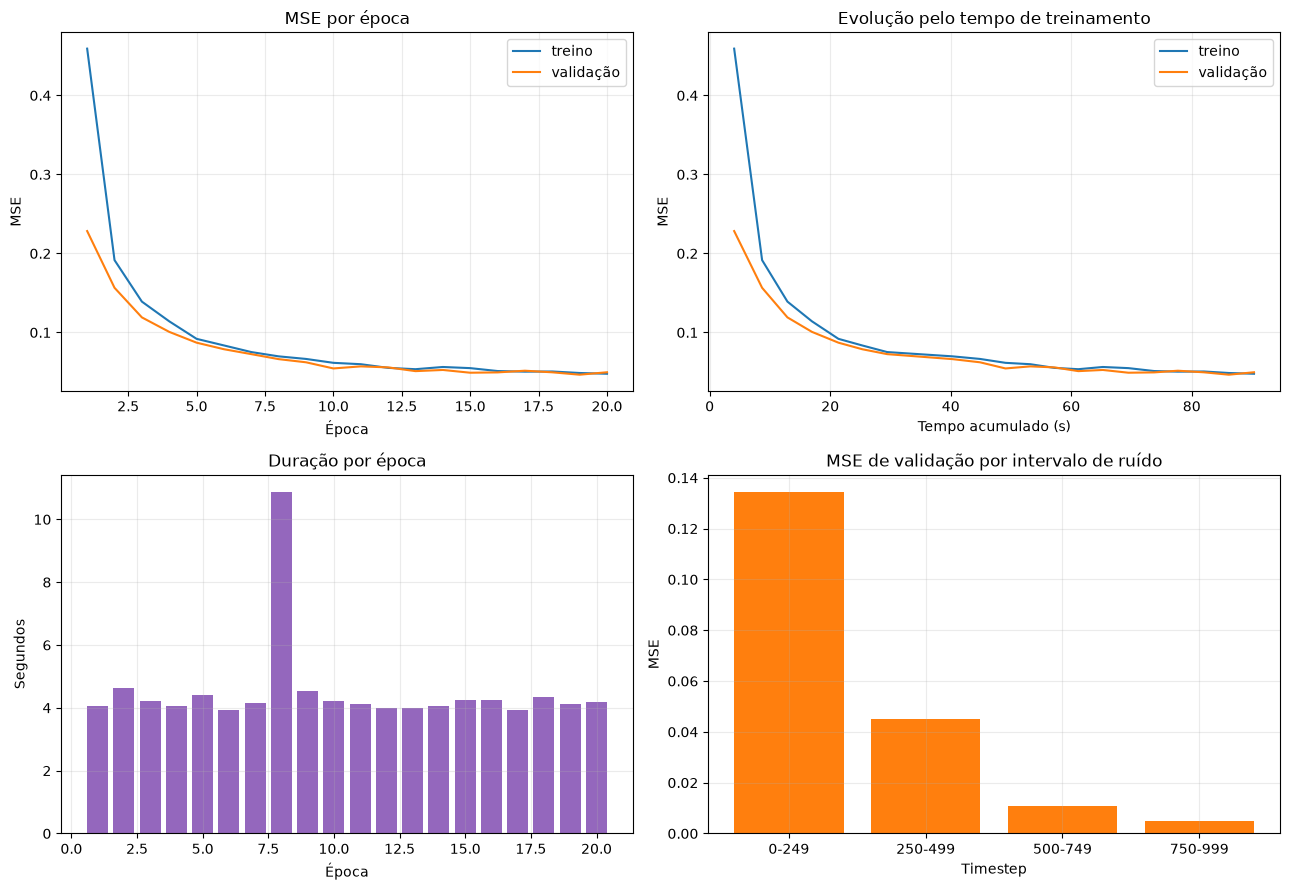

{'final_train_mse': 0.04771996161937714,
 'final_validation_mse': 0.049629004030811545,
 'total_training_seconds': 90.32546955699218,
 'mean_epoch_seconds': 4.516273477849609,
 'mean_samples_per_second': 13933.153313079116,
 'noise_band_mse': {'0-249': 0.13444344608151182,
  '250-499': 0.04518317081490342,
  '500-749': 0.010637823112156927,
  '750-999': 0.004932546569984786}}

In [68]:
@torch.inference_mode()
def evaluate_noise_mse(loader, timestep_start=0, timestep_end=T, max_batches=None):
    model.eval()
    total_loss = total_items = 0
    for batch_index, (x0, _) in enumerate(loader):
        if max_batches is not None and batch_index >= max_batches:
            break
        x0 = x0.to(DEVICE)
        timesteps = torch.randint(timestep_start, timestep_end, (x0.shape[0],), device=DEVICE)
        xt, noise = q_sample(x0, timesteps)
        total_loss += F.mse_loss(model(xt, timesteps), noise, reduction="sum").item()
        total_items += noise.numel()
    return total_loss / total_items

if CHECKPOINT.exists() and not RETRAIN:
    checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True)
    model.load_state_dict(checkpoint["model"])
    train_losses = checkpoint["train_losses"]
    valid_losses = checkpoint["valid_losses"]
    epoch_seconds = checkpoint["epoch_seconds"]
    print(f"Checkpoint e histórico carregados de {CHECKPOINT}")
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
    train_losses, valid_losses, epoch_seconds = [], [], []
    for epoch in range(EPOCHS):
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        epoch_start = time.perf_counter()
        model.train()
        total_loss = 0.0
        for x0, _ in train_loader:
            x0 = x0.to(DEVICE, non_blocking=True)
            timesteps = torch.randint(T, (x0.shape[0],), device=DEVICE)
            xt, noise = q_sample(x0, timesteps)
            loss = F.mse_loss(model(xt, timesteps), noise)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x0.shape[0]
        train_losses.append(total_loss / len(train_data))
        valid_losses.append(evaluate_noise_mse(valid_loader))
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        epoch_seconds.append(time.perf_counter() - epoch_start)
        print(f"época {epoch + 1:02d}/{EPOCHS}: treino={train_losses[-1]:.4f}, validação={valid_losses[-1]:.4f}, tempo={epoch_seconds[-1]:.2f}s")
    torch.save({"model": model.state_dict(), "train_losses": train_losses, "valid_losses": valid_losses, "epoch_seconds": epoch_seconds}, CHECKPOINT)

cumulative_seconds = np.cumsum(epoch_seconds)
throughput = np.asarray([len(train_data) / seconds for seconds in epoch_seconds])
noise_bands = [(0, 250), (250, 500), (500, 750), (750, 1_000)]
noise_band_mse = [evaluate_noise_mse(valid_loader, start, end, max_batches=4) for start, end in noise_bands]
training_metrics = {
    "final_train_mse": train_losses[-1],
    "final_validation_mse": valid_losses[-1],
    "total_training_seconds": float(cumulative_seconds[-1]),
    "mean_epoch_seconds": float(np.mean(epoch_seconds)),
    "mean_samples_per_second": float(np.mean(throughput)),
    "noise_band_mse": dict(zip([f"{start}-{end - 1}" for start, end in noise_bands], noise_band_mse)),
}
(METRICS_DIR / "training_metrics.json").write_text(json.dumps(training_metrics, indent=2, ensure_ascii=False))

epochs = np.arange(1, len(train_losses) + 1)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0, 0].plot(epochs, train_losses, label="treino")
axes[0, 0].plot(epochs, valid_losses, label="validação")
axes[0, 0].set(title="MSE por época", xlabel="Época", ylabel="MSE")
axes[0, 0].legend()
axes[0, 1].plot(cumulative_seconds, train_losses, label="treino")
axes[0, 1].plot(cumulative_seconds, valid_losses, label="validação")
axes[0, 1].set(title="Evolução pelo tempo de treinamento", xlabel="Tempo acumulado (s)", ylabel="MSE")
axes[0, 1].legend()
axes[1, 0].bar(epochs, epoch_seconds, color="tab:purple")
axes[1, 0].set(title="Duração por época", xlabel="Época", ylabel="Segundos")
axes[1, 1].bar([f"{start}-{end - 1}" for start, end in noise_bands], noise_band_mse, color="tab:orange")
axes[1, 1].set(title="MSE de validação por intervalo de ruído", xlabel="Timestep", ylabel="MSE")
for axis in axes.flat:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(METRICS_DIR / "training_metric_plots.png", dpi=150, bbox_inches="tight")
plt.show()
training_metrics

## 6. Amostragem DDPM

O processo começa em $x_T\sim\mathcal{N}(0,I)$ e percorre todos os passos de trás para frente. Aqui usamos a variância posterior $\tilde\beta_t$.

In [69]:
@torch.inference_mode()
def sample_ddpm(model, sample_count=16):
    model.eval()
    x = torch.randn(sample_count, 1, 28, 28, device=DEVICE)
    for step in reversed(range(T)):
        timesteps = torch.full((sample_count,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        mean = (x - betas[step] / torch.sqrt(1 - alpha_bars[step]) * predicted_noise) / torch.sqrt(alphas[step])
        if step > 0:
            x = mean + posterior_variance[step].sqrt() * torch.randn_like(x)
        else:
            x = mean
    return x.clamp(-1, 1)

start = time.perf_counter()
ddpm_samples = sample_ddpm(model)
ddpm_seconds = time.perf_counter() - start
print(f"DDPM: {T} avaliações da rede em {ddpm_seconds:.2f} s")

DDPM: 1000 avaliações da rede em 5.22 s


## 7. Amostragem DDIM

O DDIM reutiliza exatamente a mesma rede e pode saltar passos. O parâmetro $\eta$ controla a estocasticidade: $\eta=0$ produz a trajetória determinística e $\eta=1$ é mais robusto aos erros deste preditor pequeno. Usamos 50 passos e $\eta=1$ por padrão; troque para zero para demonstrar o regime implícito determinístico.

In [70]:
@torch.inference_mode()
def sample_ddim(model, sample_count=16, sampling_steps=40, eta=0.0):
    model.eval()
    x = torch.randn(sample_count, 1, 28, 28, device=DEVICE)
    schedule = torch.linspace(T - 1, 0, sampling_steps, device=DEVICE).long()
    assert sampling_steps <= T and torch.all(schedule[:-1] > schedule[1:])

    for index, step in enumerate(schedule):
        timesteps = torch.full((sample_count,), step, device=DEVICE, dtype=torch.long)
        predicted_noise = model(x, timesteps)
        alpha_bar = alpha_bars[step]
        previous_alpha_bar = alpha_bars[schedule[index + 1]] if index + 1 < len(schedule) else torch.tensor(1.0, device=DEVICE)
        predicted_x0 = (x - torch.sqrt(1 - alpha_bar) * predicted_noise) / torch.sqrt(alpha_bar)
        sigma = eta * torch.sqrt((1 - previous_alpha_bar) / (1 - alpha_bar) * (1 - alpha_bar / previous_alpha_bar))
        direction = torch.sqrt(torch.clamp(1 - previous_alpha_bar - sigma.square(), min=0)) * predicted_noise
        noise = torch.randn_like(x) if eta > 0 else 0.0
        x = torch.sqrt(previous_alpha_bar) * predicted_x0 + direction + sigma * noise
    return x.clamp(-1, 1)

DDIM_STEPS = 50 if QUICK_RUN else 100
DDIM_ETA = 1.0
start = time.perf_counter()
ddim_samples = sample_ddim(model, sampling_steps=DDIM_STEPS, eta=DDIM_ETA)
ddim_seconds = time.perf_counter() - start
print(f"DDIM (η={DDIM_ETA:g}): {DDIM_STEPS} avaliações da rede em {ddim_seconds:.2f} s")

DDIM (η=1): 100 avaliações da rede em 0.42 s


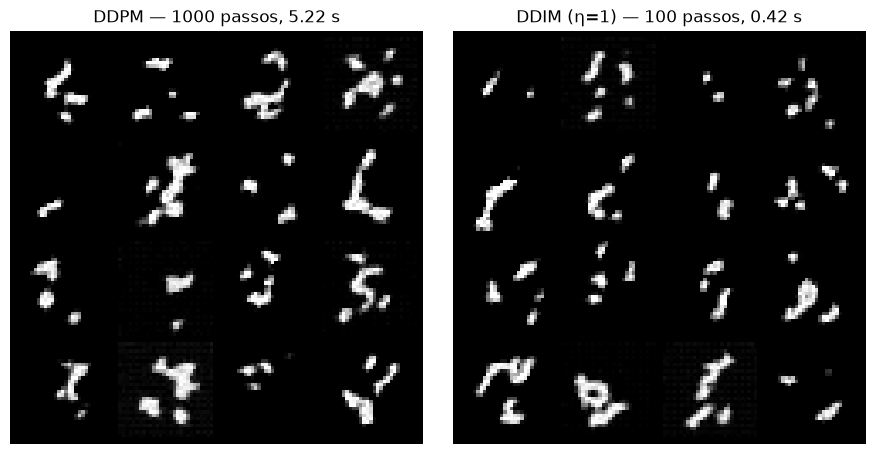

Aceleração observada nesta execução: 12.44x


In [71]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for axis, samples, title in [
    (axes[0], ddpm_samples, f"DDPM — {T} passos, {ddpm_seconds:.2f} s"),
    (axes[1], ddim_samples, f"DDIM (η={DDIM_ETA:g}) — {DDIM_STEPS} passos, {ddim_seconds:.2f} s"),
]:
    grid = make_grid((samples.cpu() + 1) / 2, nrow=4)
    axis.imshow(grid.permute(1, 2, 0).clip(0, 1))
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
plt.show()
print(f"Aceleração observada nesta execução: {ddpm_seconds / ddim_seconds:.2f}x")

## 8. Métricas comparativas das amostras

Comparamos DDPM e DDIM por latência, vazão, diversidade entre amostras, distância ao MNIST real mais próximo, nitidez e diferença dos dois primeiros momentos dos pixels. São diagnósticos relativos desta execução, não substitutos de FID.

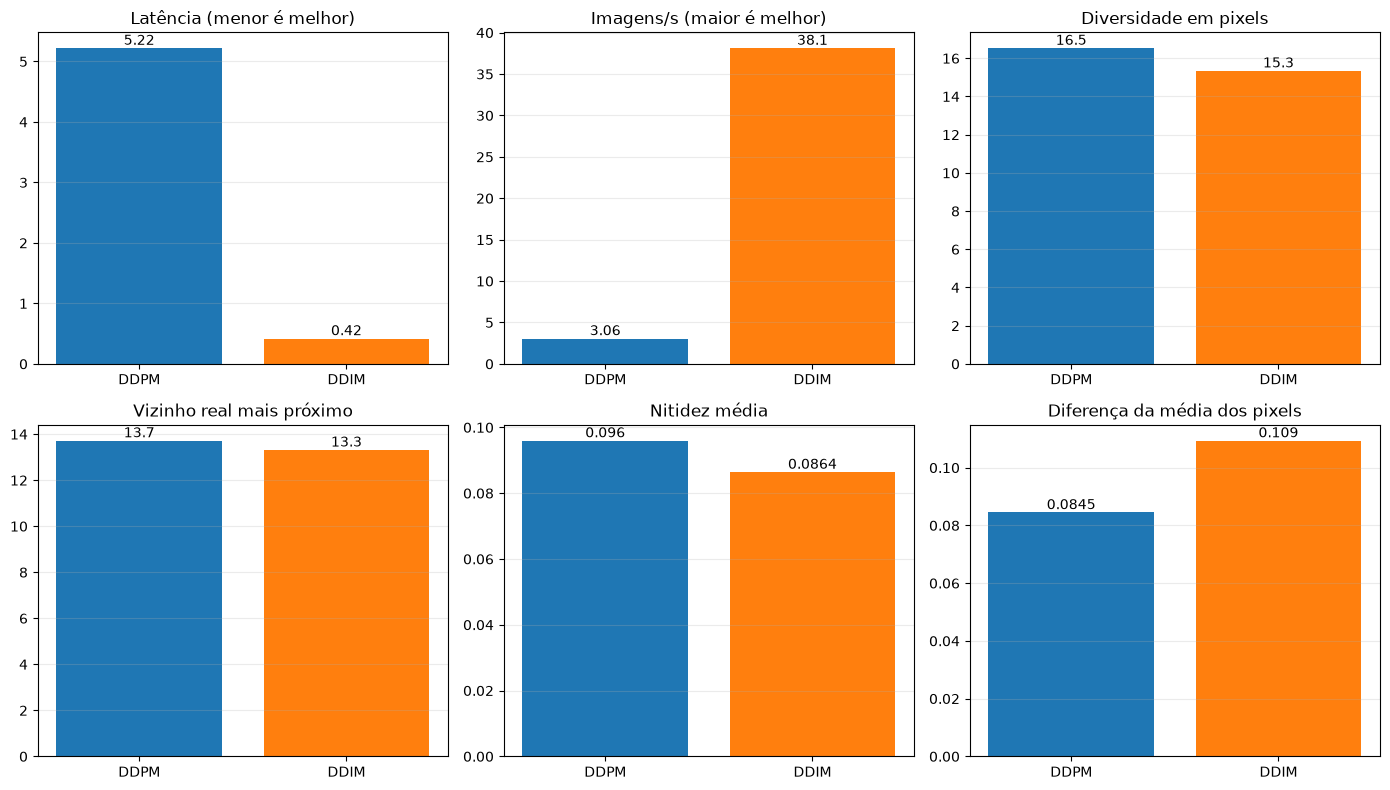

{'DDPM': {'seconds': 5.220951085007982,
  'images_per_second': 3.0645757333264765,
  'pixel_diversity': 16.53281593322754,
  'nearest_real_distance': 13.720316886901855,
  'sharpness': 0.09598211944103241,
  'pixel_mean_gap': 0.08449375629425049,
  'pixel_std_gap': 0.13139274716377258},
 'DDIM': {'seconds': 0.4195784290059237,
  'images_per_second': 38.133514246448804,
  'pixel_diversity': 15.348763465881348,
  'nearest_real_distance': 13.318025588989258,
  'sharpness': 0.08641856908798218,
  'pixel_mean_gap': 0.10938495397567749,
  'pixel_std_gap': 0.16819018125534058}}

In [72]:
reference_images, _ = next(iter(valid_loader))
reference_images = reference_images[:128].to(DEVICE)

def sample_statistics(samples, elapsed_seconds):
    flat_samples = samples.flatten(1)
    flat_reference = reference_images.flatten(1)
    vertical_edges = (samples[:, :, 1:, :] - samples[:, :, :-1, :]).abs().mean()
    horizontal_edges = (samples[:, :, :, 1:] - samples[:, :, :, :-1]).abs().mean()
    return {
        "seconds": elapsed_seconds,
        "images_per_second": len(samples) / elapsed_seconds,
        "pixel_diversity": torch.pdist(flat_samples).mean().item(),
        "nearest_real_distance": torch.cdist(flat_samples, flat_reference).min(1).values.mean().item(),
        "sharpness": ((vertical_edges + horizontal_edges) / 2).item(),
        "pixel_mean_gap": abs(samples.mean().item() - reference_images.mean().item()),
        "pixel_std_gap": abs(samples.std().item() - reference_images.std().item()),
    }

generation_metrics = {
    "DDPM": sample_statistics(ddpm_samples, ddpm_seconds),
    "DDIM": sample_statistics(ddim_samples, ddim_seconds),
}
(METRICS_DIR / "generation_metrics.json").write_text(json.dumps(generation_metrics, indent=2, ensure_ascii=False))

metric_names = ["seconds", "images_per_second", "pixel_diversity", "nearest_real_distance", "sharpness", "pixel_mean_gap"]
metric_titles = ["Latência (menor é melhor)", "Imagens/s (maior é melhor)", "Diversidade em pixels", "Vizinho real mais próximo", "Nitidez média", "Diferença da média dos pixels"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for axis, metric_name, title in zip(axes.flat, metric_names, metric_titles):
    values = [generation_metrics[sampler][metric_name] for sampler in ("DDPM", "DDIM")]
    bars = axis.bar(["DDPM", "DDIM"], values, color=["tab:blue", "tab:orange"])
    axis.bar_label(bars, fmt="%.3g")
    axis.set_title(title)
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(METRICS_DIR / "generation_metric_plots.png", dpi=150, bbox_inches="tight")
plt.show()
generation_metrics

## 9. Discussão

- O processo direto confirma visualmente a perda gradual de informação prevista por $q(x_t\mid x_0)$.
- O treino implementa o objetivo de predição de ruído do DDPM sem alterar sua forma matemática.
- As curvas por época e por tempo mostram convergência, custo e diferença entre treino e validação.
- A MSE por intervalo de timestep revela em quais níveis de ruído o preditor encontra maior dificuldade.
- O DDIM reduz o número de avaliações da mesma rede; a aceleração medida depende do hardware.
- A qualidade fica abaixo dos artigos por usarmos menos dados, passos, épocas e uma arquitetura muito menor. Comparar FID não seria válido neste recorte.

### Artigos locais

1. Ho, J.; Jain, A.; Abbeel, P. *Denoising Diffusion Probabilistic Models*. NeurIPS, 2020.
2. Song, J.; Meng, C.; Ermon, S. *Denoising Diffusion Implicit Models*. ICLR, 2021.
3. Ghojogh, B.; Ghodsi, A. *Diffusion Models: Tutorial and Survey*. 2024.
4. Yang, L. et al. *Diffusion Models: A Comprehensive Survey of Methods and Applications*. ACM Computing Surveys, 2023.